# How to save your model results

Hopefully you've managed to get some calculations run using PetThermoTools and are now thinking about how to best save your results so that you don't have to rerun the calculations everytime you come back to a notebook. In this example we'll run some basic crystallization calculations (the same as seen in the crystallization examples) and then go through three different ways to save your results!

Data used in the calculations below can be downloaded from here: https://github.com/gleesonm1/PetThermoTools/blob/master/docs/Examples/CrystallisationTests/Fernandina_glass.xlsx

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If the alphaMELTS for Python files have not been added to your Python path (see installation guide) then use the two lines below to add
# the location of the alphaMELTS files here.
# import sys
# sys.path.append(r'C:\Users\penny\Box\Berkeley_new\MELTS_Installation\alphamelts_py\alphamelts-py-2.3.1-win64')

# Now run this and itll check you have added it properly
import petthermotools as ptt

alphaMELTS for Python files successfully located.


In [3]:
# Should be used to suppress outputs on MacOS - run twice
import platform
if platform.system() == "Darwin":
    import sys
    import os 
    sys.stdout = open(os.devnull, 'w')
    sys.stderr = open(os.devnull, 'w')

As in the main crystallization example we're going to run some fractional crystallization models using glass compositions from Isla Fernandina in the Galapagos Archipelago, where a series of melt inclusions (Koleszar et al. 2009) and matrix glasses (Peterson et al. 2017) provide us with plenty of glass data to constain the magmatic evolution of the sub-volcanic system. The melt inclusion and matrix glass data is included in a single excel spreadsheet that we can load in using Pandas. We can also split this DataFrame into two. One containing just the melt inclusion data, the second including just the matrix glass data.

In [4]:
df = pd.read_excel('Fernandina_glass.xlsx')
df = df.fillna(0)

# split data based on the Group (Melt Inclusion or Matrix Glass)
MI = df.loc[df['Group'] == 'MI',:].reset_index(drop = True)
MG = df.loc[df['Group'] == 'MG',:].reset_index(drop = True)

MG.head()

,Group,Latitude,Longitude,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,P2O5,H2O,CO2
0,MG,-0.17,-91.77,49.11,2.90,14.04,11.38,0.21,6.53,11.88,2.55,0.43,0.30,0.593,0.011442
1,MG,-0.17,-91.77,49.22,3.10,14.09,11.37,0.20,6.75,11.78,2.75,0.44,0.31,0.683,0.009890
2,MG,-0.21,-91.81,49.01,2.92,13.92,11.74,0.21,6.31,11.90,2.55,0.46,0.33,0.635,0.012210
3,MG,-0.21,-91.80,49.42,3.14,13.92,11.77,0.20,6.47,11.46,2.82,0.46,0.33,0.732,0.010531
4,MG,-0.24,-91.75,48.76,3.57,13.88,11.83,0.23,6.37,11.40,3.09,0.52,0.36,0.834,0.007797


We can then identify the most MgO rich composition for use as our starting composition

In [5]:
MI = MI.sort_values('MgO', ascending = False, ignore_index = True)
MI.head()

,Group,Latitude,Longitude,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,P2O5,H2O,CO2
0,MI,0.0,0.0,47.5,2.29,16.4,9.16,0.123,9.38,11.6,2.25,0.329,0.257,0.68,0.0280
1,MI,0.0,0.0,47.5,2.58,15.5,10.04,0.138,8.97,11.4,2.44,0.428,0.262,0.69,0.0630
2,MI,0.0,0.0,49.2,2.33,16.0,8.67,0.147,8.94,12.0,1.78,0.005,0.094,0.78,0.0004
3,MI,0.0,0.0,48.4,2.50,15.7,9.07,0.139,8.88,11.6,2.18,0.398,0.326,0.69,0.0126
4,MI,0.0,0.0,48.1,2.46,15.3,8.96,0.153,8.82,12.1,2.34,0.325,0.387,0.88,0.4986


In [6]:
starting_comp = MI.loc[0]
starting_comp

Group           MI
Latitude       0.0
Longitude      0.0
SiO2          47.5
TiO2          2.29
Al2O3         16.4
FeOt          9.16
MnO          0.123
MgO           9.38
CaO           11.6
Na2O          2.25
K2O          0.329
P2O5         0.257
H2O           0.68
CO2          0.028
Name: 0, dtype: object

We can now perform crystallisation calculations. These calculations are run using rhyoliteMELTSv1.2.0 (we have some CO$_2$ in the starting composition), start at the liquidus and end at 1100$^o$C. The calculations are also run at 1 log unit below the FMQ buffer. By specifying Frac_solid = True, we inform PetThermoTools that we want to perform a fractional (rather than equilibrium) crystallisation scenario. In this example I'm only going to run a single calculation at a pressure of 2000 bars.

In [7]:
Isobaric_Xtal = ptt.isobaric_crystallisation(Model = "MELTSv1.2.0",
                                           bulk = starting_comp,
                                           find_liquidus = True,
                                           P_bar = 2000,
                                           T_end_C = 1100,
                                           dt_C = 2,
                                           fO2_buffer = "FMQ",
                                           fO2_offset = -1.0,
                                           Frac_solid = True,
                                           Frac_fluid = True)

There are a couple of ways to save this calculation. Remember, for a single calculation the results are returned as a Dictionary with individual DataFrames for each phase etc. but there is also the "All" DataFrame which combines all the information into one larger DataFrame. One of the easiest ways to export the results is to copy this "All" DataFrame to  an excel file.

In [9]:
Isobaric_Xtal["All"].to_excel("All_output.xlsx")

However this only saves the one DataFrame, which while useful and interesting, potentially is a little too large/complex for users to easily extract the information they need. Instead, one potential option is to export every DataFrame in the output dictionary to a different sheet of an Excel file (i.e., imagine the excel file as the overall dictionary with each sheet representing one of the output DataFrames). This can easily be done using the code cell below. In later versions of PetThermoTools I intend to build this in as a function.

In [14]:
import re

file_path = "isobaric_xtal.xlsx"

invalid_chars = r'[\[\]\:\*\?\/\\]'

def clean_sheet_name(name):
    clean_name = re.sub(invalid_chars, "_", name)
    return clean_name[:31]

with pd.ExcelWriter(file_path) as writer:
    for original_key, data in Isobaric_Xtal.items():
        sheet_name = clean_sheet_name(original_key)
        if type(data) != dict:
            data.to_excel(writer, sheet_name=sheet_name)

One of the reasons for building this as a function is that we have to make a small name change to one of the variables: `rho_kg/m3` becomes `rho_kg_m3` as the '/' is not allowed in the sheet name. Once this is built as a function I'll also develop a load function that allows you to import excel files exported in this manner and 'corrects' the key for the rho DataFrame.

Until then, you can reload this model easily using Pandas:

In [15]:
reload_isobaric_xtal = pd.read_excel("isobaric_xtal.xlsx", sheet_name=None)

and examine the results using the harker function:

(<Figure size 960x900 with 9 Axes>,
 array([[<Axes: xlabel='MgO', ylabel='SiO$_2$'>,
         <Axes: xlabel='MgO', ylabel='TiO$_2$'>,
         <Axes: xlabel='MgO', ylabel='Al$_2$O$_3$'>],
        [<Axes: xlabel='MgO', ylabel='FeO$_t$'>,
         <Axes: xlabel='MgO', ylabel='CaO'>,
         <Axes: xlabel='MgO', ylabel='Na$_2$O'>],
        [<Axes: xlabel='MgO', ylabel='K$_2$O'>, <Axes: >, <Axes: >]],
       dtype=object))

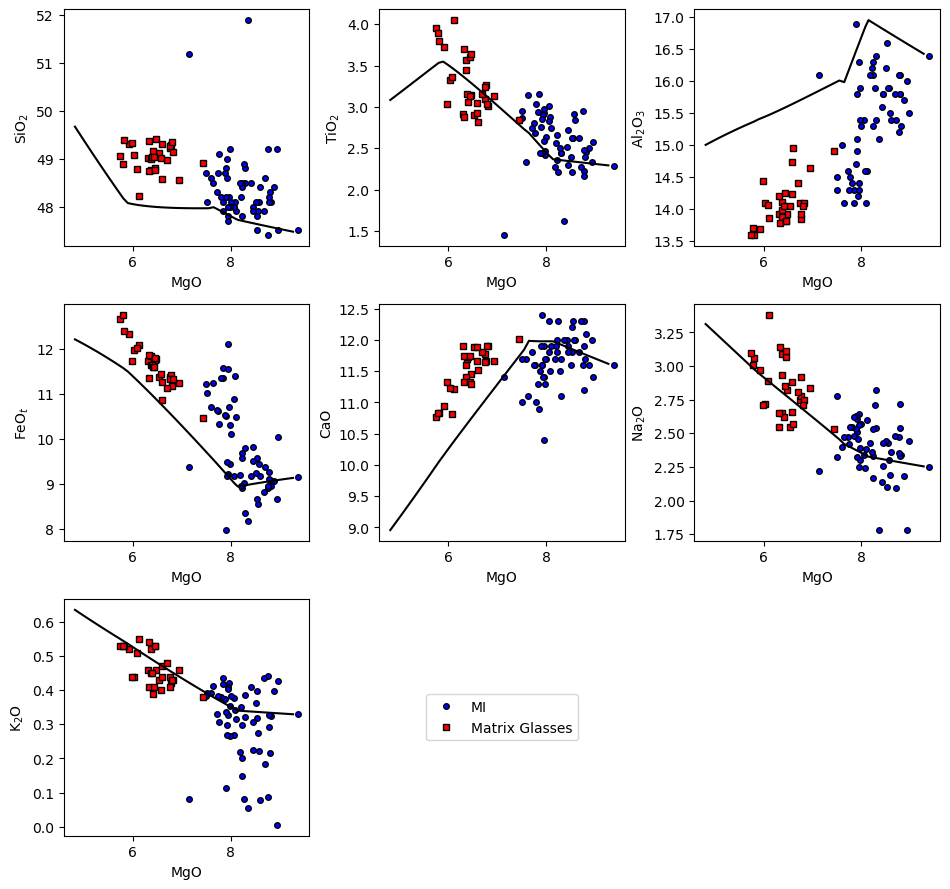

In [17]:
ptt.harker(Results = reload_isobaric_xtal, data = {'MI': MI, 'Matrix Glasses': MG},
    d_color = ['b','red'])

## What about calculations with multiple models?

When running multiple models the output options are similar. You could use the code above to generate a new excel file for every calculation that you run. However, if you're running 10s to 100s of calculations this can get quite messy quite quickly! For cases when you're running large numbers of calculations I instead suggest that you use `pickle` to export (and reload) the results:

In [18]:
Isobaric_Xtal_multi = ptt.isobaric_crystallisation(Model = "MELTSv1.2.0",
                                           bulk = starting_comp,
                                           find_liquidus = True,
                                           P_bar = [500,1000,2000,4000],
                                           T_end_C = 1100,
                                           dt_C = 2,
                                           fO2_buffer = "FMQ",
                                           fO2_offset = -1.0,
                                           Frac_solid = True,
                                           Frac_fluid = True,
                                           label = "P_bar")

In [19]:
Isobaric_Xtal_multi.keys()

dict_keys(['P = 500.0 bars', 'P = 1000.0 bars', 'P = 2000.0 bars', 'P = 4000.0 bars'])

Running the cell below will export all 4 calculations performed above as a single .pkl file

In [20]:
import pickle

with open('multi_xtal.pkl', 'wb') as f:
    pickle.dump(Isobaric_Xtal_multi, f)
    

and to 'reload' it:

In [21]:
with open('multi_xtal.pkl', 'rb') as f:
    reload_isobaric_multi = pickle.load(f)

(<Figure size 960x900 with 9 Axes>,
 array([[<Axes: xlabel='MgO', ylabel='SiO$_2$'>,
         <Axes: xlabel='MgO', ylabel='TiO$_2$'>,
         <Axes: xlabel='MgO', ylabel='Al$_2$O$_3$'>],
        [<Axes: xlabel='MgO', ylabel='FeO$_t$'>,
         <Axes: xlabel='MgO', ylabel='CaO'>,
         <Axes: xlabel='MgO', ylabel='Na$_2$O'>],
        [<Axes: xlabel='MgO', ylabel='K$_2$O'>, <Axes: >, <Axes: >]],
       dtype=object))

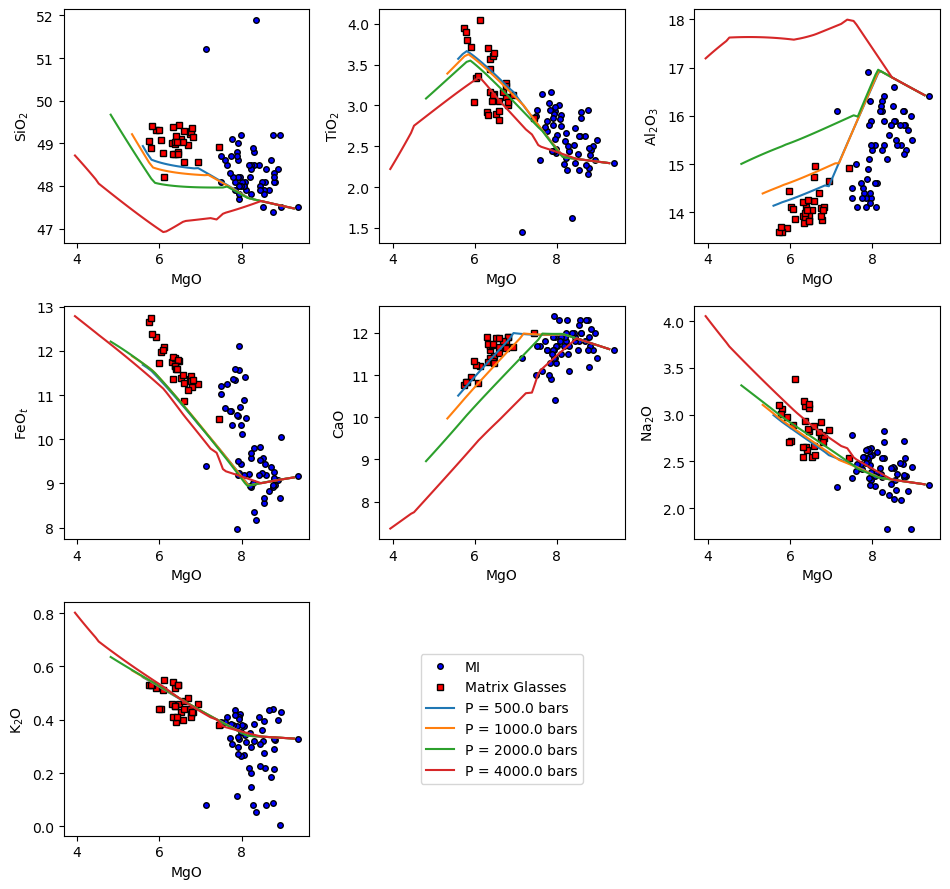

In [22]:
ptt.harker(Results = reload_isobaric_multi, data = {'MI': MI, 'Matrix Glasses': MG},
    d_color = ['b','red'])